<a href="https://colab.research.google.com/github/skabdultousif06/AI-LAB-/blob/main/LAB1_Problem3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib

Problem 3: Checking Routes Between Cities Using DFS Problem Statement: A small road network connects several cities. Write a Python program using DFS that:

Checks whether a route exists between two given cities. Finds all separate groups of cities that are connected to each other but not to any other group (these are called connected components).

Checking whether a road route exists between cities using DFS:

 Kolkata -> Ranchi ? YES, a route exists
 Kolkata -> Mumbai ? NO route exists
 Bankura -> Dhanbad ? YES, a route exists

Finding all separate groups of connected cities:
 Group 1: ['Kolkata', 'Durgapur', 'Bankura', 'Asansol', 'Dhanbad', 'Ranchi']
 Group 2: ['Mumbai', 'Pune']


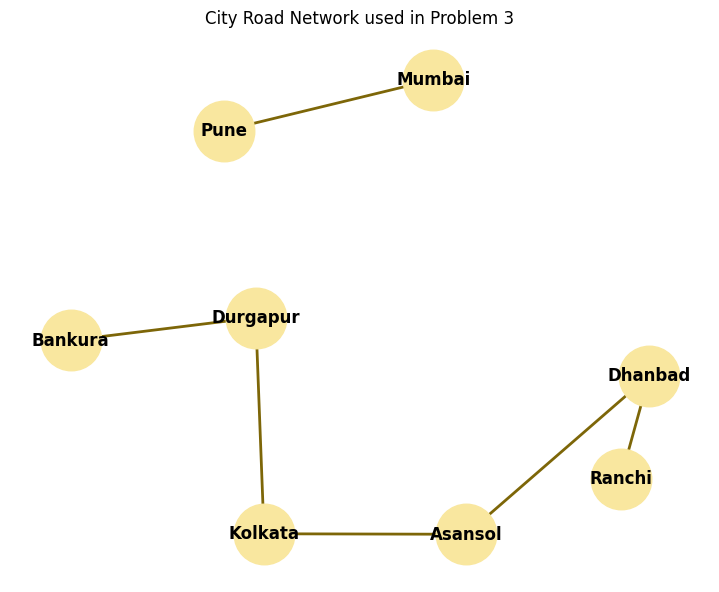

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
# Step 1: Represent a small road network as a graph (adjacency list)
# Notice 'Mumbai' and 'Pune' are connected to each other, but NOT to the rest of the map.
city_graph = {
'Kolkata': ['Durgapur', 'Asansol'],
'Durgapur': ['Kolkata', 'Bankura'],
'Asansol': ['Kolkata', 'Dhanbad'],
'Bankura': ['Durgapur'],
'Dhanbad': ['Asansol', 'Ranchi'],
'Ranchi': ['Dhanbad'],
'Mumbai': ['Pune'],
'Pune': ['Mumbai']
}
# Step 2: DFS function that checks if a path exists between two cities
def dfs_path_exists(graph, current_city, destination_city, visited=None):
    if visited is None:
        visited = set()
    visited.add(current_city)
    if current_city == destination_city:
        return True
    for neighbour_city in graph[current_city]:
        if neighbour_city not in visited:
            if dfs_path_exists(graph, neighbour_city, destination_city, visited):
                return True
    return False
# Step 3: DFS function that returns the full visited order (for connected components)
def dfs_traversal(graph, start_city, visited=None):
    if visited is None:
        visited = set()
    order = []
    visited.add(start_city)
    order.append(start_city)
    for neighbour_city in graph[start_city]:
        if neighbour_city not in visited:
            order.extend(dfs_traversal(graph, neighbour_city, visited))
    return order
# Step 4: Test whether a route exists between different city pairs
pairs_to_check = [('Kolkata', 'Ranchi'), ('Kolkata', 'Mumbai'), ('Bankura', 'Dhanbad')]
print("Checking whether a road route exists between cities using DFS:\n")
for city_a, city_b in pairs_to_check:
    result = dfs_path_exists(city_graph, city_a, city_b)
    status = "YES, a route exists" if result else "NO route exists"
    print(f" {city_a} -> {city_b} ? {status}")
# Step 5: Find all separate (disconnected) groups of cities using DFS
print("\nFinding all separate groups of connected cities:")
all_cities = list(city_graph.keys())
visited_overall = set()
group_number = 1
for city in all_cities:
    if city not in visited_overall:
        group = dfs_traversal(city_graph, city, visited_overall)
        print(f" Group {group_number}: {group}")
        group_number += 1
# Step 6: Draw the map
G = nx.Graph()
for city, neighbours in city_graph.items():
    for n in neighbours:
        G.add_edge(city, n)
plt.figure(figsize=(7, 5.5))
pos = nx.spring_layout(G, seed=11, k=1.6)
nx.draw(G, pos, with_labels=True, node_color='#F9E79F', node_size=1900,
font_size=12, font_weight='bold', edge_color='#7D6608', width=2)
plt.title("City Road Network used in Problem 3")
plt.show()